In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


**Column details:**

1. `longitude`: A measure of how far west a house is; a higher value is farther west

2. `latitude`: A measure of how far north a house is; a higher value is farther north

3. `housingMedianAge`: Median age of a house within a block; a lower number is a newer building

4. `totalRooms`: Total number of rooms within a block

5. `totalBedrooms`: Total number of bedrooms within a block

6. `population`: Total number of people residing within a block

7. `households`: Total number of households, a group of people residing within a home unit, for a block

8. `medianIncome`: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. `medianHouseValue`: Median house value for households within a block (measured in US Dollars)

10. `oceanProximity`: Location of the house w.r.t ocean/sea

## Exploring the Data

In [6]:
target_col = 'median_house_value'

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Target Column: ", target_col)
print("\nNumerical Column: ",num_cols)
print("\nCategorical Column: ",cat_cols)

Target Column:  median_house_value

Numerical Column:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

Categorical Column:  ['ocean_proximity']


In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
# Check presence of Encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))  # Top 20 values in each column

longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
-118.28    141
-118.35    140
-118.36    138
-118.19    135
-118.25    128
-118.37    128
-118.20    126
-118.14    125
-118.26    121
-118.13    121
-118.18    120
-118.34    119
-118.21    118
-118.15    116
-118.12    112
Name: count, dtype: int64
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
34.09    212
34.02    208
34.10    203
34.03    193
33.93    181
33.94    175
33.97    172
33.99    168
33.88    164
33.98    162
34.11    162
34.16    159
34.12    158
34.15    157
34.01    156
Name: count, dtype: int64
housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
Name: count, dtype: int64
total_rooms
1527.0    18
1613.0    17
1582.0    17
2127.0    16


In [9]:
print('No of duplicate rows:',df.duplicated().sum())

No of duplicate rows: 0


In [10]:
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Exploratory Data Analysis (EDA)

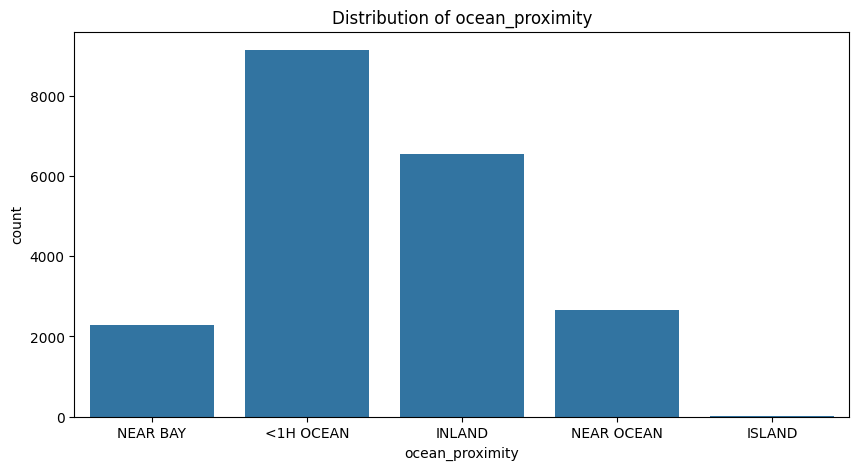

In [11]:
for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

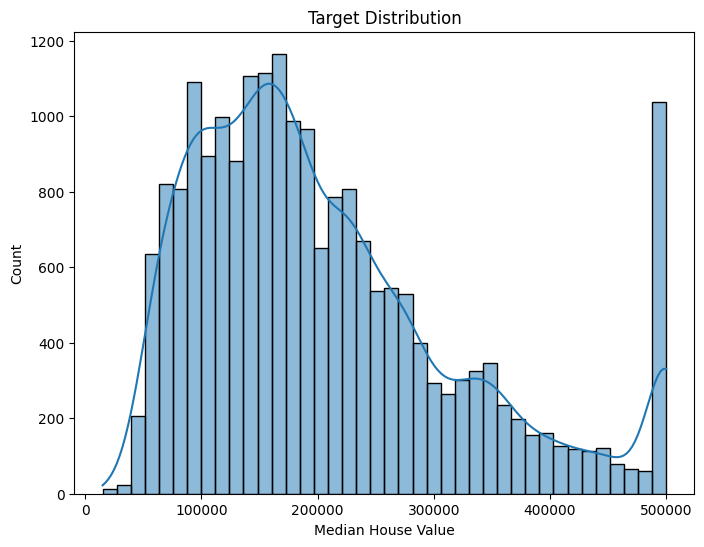

In [12]:
plt.figure(figsize=(8,6))
sns.histplot(df['median_house_value'],bins=40,kde=True)
plt.title("Target Distribution")
plt.xlabel('Median House Value')
plt.show()

In [13]:
df['median_house_value'].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
34200.0       1
46200.0       1
352000.0      1
307900.0      1
385200.0      1
Name: count, Length: 3842, dtype: int64

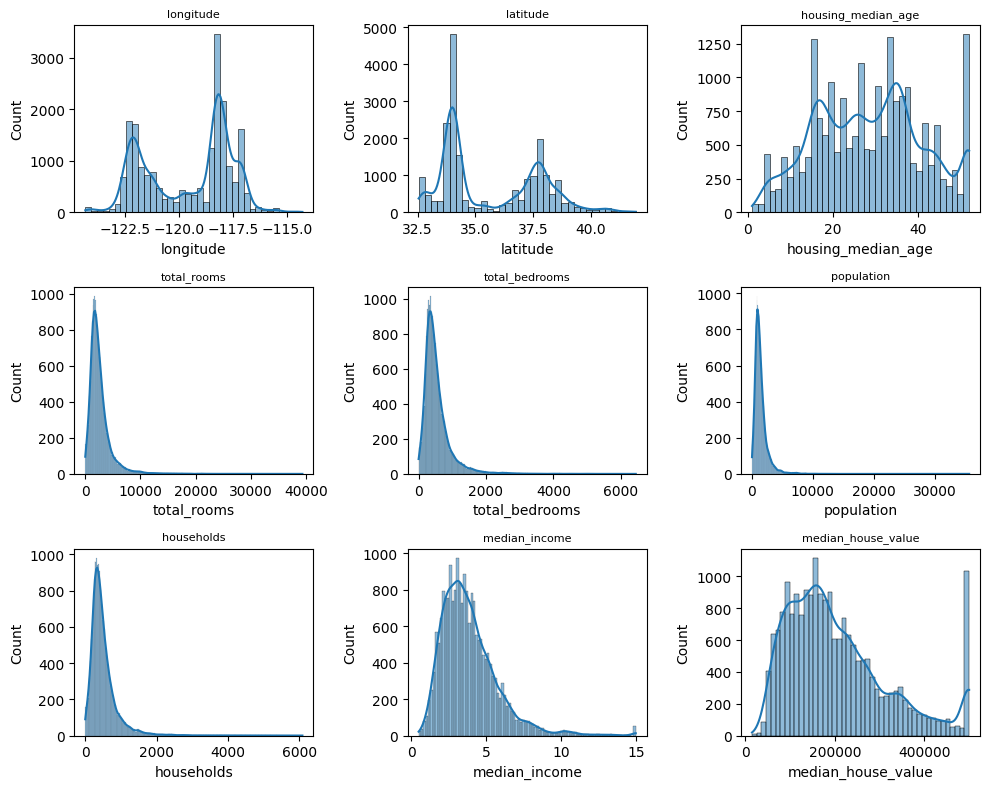

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

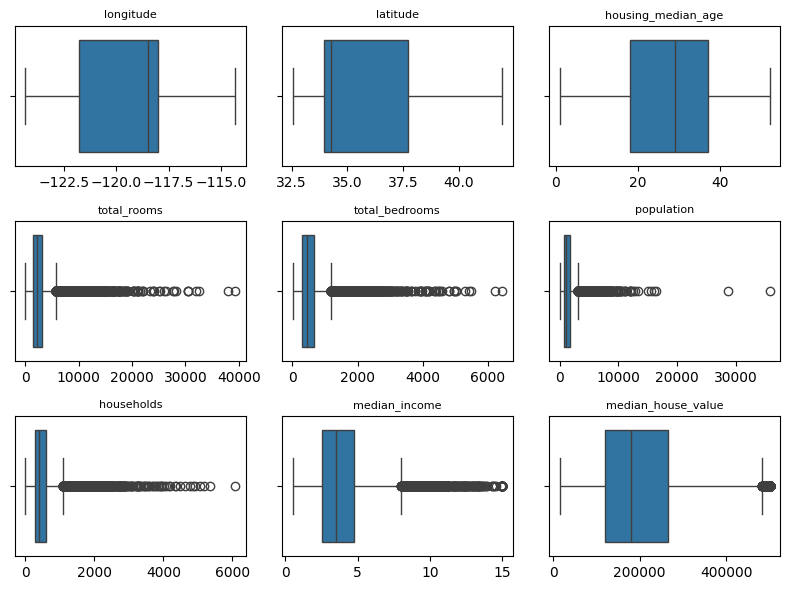

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

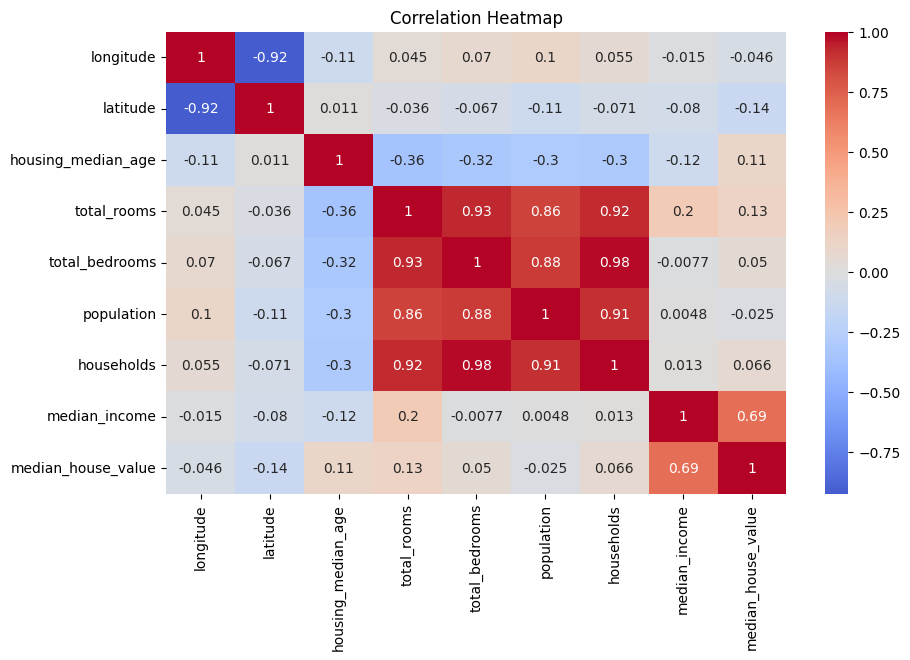

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(),annot=True,cmap="coolwarm",center=0)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Correlation with target
corr_with_target = df[num_cols].corr()['median_house_value'].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


## Data Pre-processing

In [18]:
TARGET_COL = 'median_house_value'

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X.shape , y.shape

((20640, 9), (20640,))

In [19]:
X.head(4)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY


In [20]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

X_train.shape , X_test.shape

((16512, 9), (4128, 9))

In [21]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

numerical_transformer = Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="median")),
                                    ("scaler", StandardScaler())
                                ]
                            )

categorical_transformer = Pipeline(
                                steps=[
                                    ("imputer", SimpleImputer(strategy="most_frequent")),
                                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                                ]
                            )


Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


In [22]:
preprocess = ColumnTransformer(
                                transformers=[
                                    ("num", numerical_transformer, numerical_features),
                                    ("cat", categorical_transformer, categorical_features)
                                ]
                            )

## Baseline Model

In [23]:
baseline_pipe = Pipeline(steps=[
                            ('preprocess',preprocess),
                            ('model',LinearRegression())
                        ])

In [24]:
baseline_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [25]:
train_baseline_pred = baseline_pipe.predict(X_train)

test_baseline_pred = baseline_pipe.predict(X_test)

In [26]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 68433.937
MAE : 49594.842
R2  : 0.650


In [27]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 70059.193
MAE : 50670.489
R2  : 0.625


## Model Selection and Optimization

In [32]:
models = {
            "LinearRegression": LinearRegression(),
            "Ridge": Ridge(random_state=42),
            "Lasso": Lasso(random_state=42, max_iter=10000),
            "RandomForest": RandomForestRegressor(),
            "HistGB": HistGradientBoostingRegressor()
        }

In [33]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)


In [34]:
scoring = {
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        }

In [ ]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")

In [40]:
print("=== CV Model Comparison ===\n")
cv_results

=== CV Model Comparison ===



,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48069.248861,32199.076673,0.827102
3,RandomForest,49380.544685,32231.409173,0.817554
1,Ridge,68595.617399,49664.330927,0.647760
2,Lasso,68603.233277,49667.262611,0.647685
0,LinearRegression,68604.162955,49667.159067,0.647676


In [41]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : HistGB
CV RMSE: 48069.248860834


## HyperParameter Tuning

In [42]:
hgb_pipe = Pipeline(
                steps=[
                    ("preprocess", preprocess),
                    ("model", HistGradientBoostingRegressor(random_state=42))
                ]
            )

In [43]:
param_grid = {
                "model__learning_rate": [0.03, 0.05, 0.1],
                "model__max_depth": [None, 3, 6],
                "model__max_leaf_nodes": [15, 31, 63],
                "model__min_samples_leaf": [20, 50, 100],
                "model__l2_regularization": [0.0, 0.1, 1.0]
            }

In [44]:
grid = GridSearchCV(estimator=hgb_pipe, param_grid=param_grid,
                    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,verbose=1)

In [45]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [46]:
print("\n=== TUNED HistGB (CV) ===\n")

print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED HistGB (CV) ===

Best CV RMSE: 47408.38131673431
Best params: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


## Retraining with Best Parameters

In [47]:
hgb_best = Pipeline(
                    steps=[
                        ("preprocess", preprocess),
                        ("model", HistGradientBoostingRegressor(
                                                            l2_regularization=0.1,
                                                            learning_rate=0.1,
                                                            max_depth=None,
                                                            max_leaf_nodes=63,
                                                            min_samples_leaf=20
                                                        ))
                    ]
                )

In [48]:
hgb_best.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

In [49]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

In [50]:
print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===\n")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Train Performance ===

RMSE: 35932.619
MAE : 24487.594
R2  : 0.903


In [51]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

In [52]:
print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE: 46516.744
MAE : 30650.971
R2  : 0.835


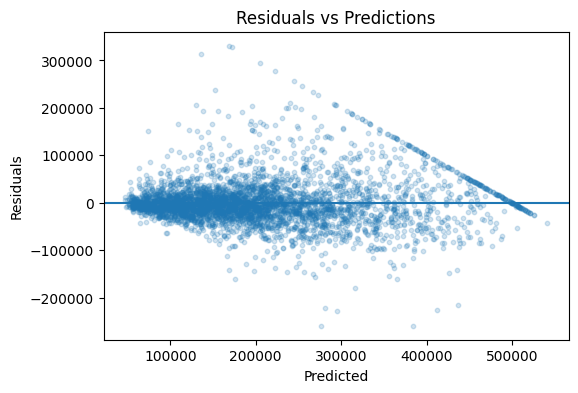

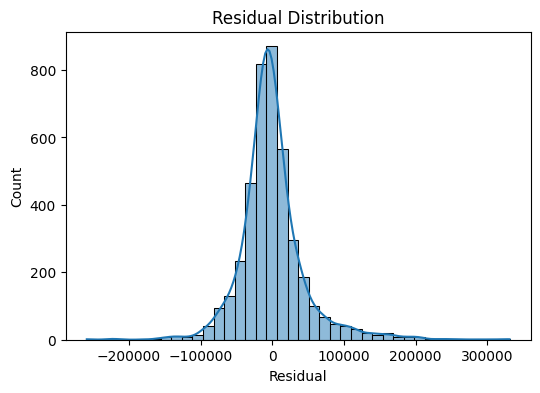

In [55]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10,alpha=0.2)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

## Prediction

In [ ]:
def predict_house_price(model,
                        longitude: float,latitude: float,
                        housing_median_age: float,
                        total_rooms: float,total_bedrooms: float,
                        population: float,households: float,
                        median_income: float, ocean_proximity: str):
    """
    Predict median_house_value for one new house.
    """

    new_row = pd.DataFrame([{
                    "longitude": longitude,
                    "latitude": latitude,
                    "housing_median_age": housing_median_age,
                    "total_rooms": total_rooms,
                    "total_bedrooms": total_bedrooms,
                    "population": population,
                    "households": households,
                    "median_income": median_income,
                    "ocean_proximity": ocean_proximity
                }])

    return float(model.predict(new_row)[0])

In [57]:
# Example inference
example_pred = predict_house_price(
                                    model=hgb_best,
                                    longitude=-122.230,
                                    latitude=37.880,
                                    housing_median_age=41,
                                    total_rooms=880,
                                    total_bedrooms=129,
                                    population=322,
                                    households=126,
                                    median_income=8.3252,
                                    ocean_proximity="NEAR BAY"
                                )

print("\nExample prediction:", round(example_pred, 2))


Example prediction: 439690.48


## Saving the Model

In [63]:
import pickle

In [64]:
pickle.dump(hgb_best,open("model.pkl","wb"))